In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from keras.datasets import mnist
from tqdm import tqdm
from sklearn.metrics import accuracy_score

def one_hot(train_y):
    y_train_one_hot = np.zeros((len(train_y), 10))
    # ok i looked this following line on the internet 
    y_train_one_hot[np.arange(len(train_y)), train_y] = 1
    return y_train_one_hot

(train_X, train_y), (test_X, test_y) = mnist.load_data()
train_X = train_X.reshape(60000,28*28)/255
test_X = test_X.reshape(10000,28*28)/255
train_y = one_hot(train_y)
test_y = one_hot(test_y)
'''
train_X = train_X[:1,]
train_y = train_y[:1,]'''


print('X_train: ' + str(train_X.shape))
print('Y_train: ' + str(train_y.shape))
print('X_test:  '  + str(test_X.shape))
print('Y_test:  '  + str(test_y.shape))

X_train: (60000, 784)
Y_train: (60000, 10)
X_test:  (10000, 784)
Y_test:  (10000, 10)


In [2]:
N1 = 100
N2 = 20
learning_rate = 0.1
batchsize = 100

In [3]:
def example():
    index = np.random.randint(0,train_X.shape[0])
    random_img = train_X[index,:].reshape(1,-1)
    reponse = train_y[index,:]
    side_length = 28
    image_matrix = random_img.reshape((side_length, side_length))
    pred = predict(random_img, W0, b0, W1, b1, W2, b2)
    print('pred :',np.where(pred == 1)[1])
    print('le nombre :',np.where(reponse == 1)[0])
    plt.imshow(image_matrix, cmap='gray')
    plt.axis('off')  # Hide axes
    plt.show()

In [4]:
def initialisation(X,N1,N2,y):
    W0 = np.random.rand(X.shape[1],N1)-0.5
    W1 = np.random.rand(N1,N2)-0.5
    W2 = np.random.rand(N2,y.shape[1])-0.5

    b0 = np.random.rand(1,N1)-0.5
    b1 = np.random.rand(1,N2)-0.5
    b2 = np.random.rand(1,y.shape[1])-0.5
    return W0,W1,W2,b0,b1,b2

In [5]:
def new_batch(X,y,batchsize):
    n = np.random.randint(0,X.shape[0]-1)
    if n > (X.shape[0] / 2):
        X = X[n-batchsize:n,:]
        y = y[n-batchsize:n,:]
    else:
        X = X[n:n+batchsize,:]
        y = y[n:n+batchsize,:]
    return X,y

In [6]:
def reLU(Z):
    return np.maximum(Z,0)
def reLU_derivative(Z):
    return Z>0
def SoftPlus(Z):
    Z[Z>150] = 150
    return np.log(1 + np.exp(Z))
def SoftPlus_derivative(Z):
    return 1 / ( 1 + np.exp(-Z))
def sigmoid(Z):
    A = 1/(1+np.exp(-Z))
    return A
def sigmoid_derivative(A):
    return A * (1 - A)
def softmax(z):
    z[z>150] = 150
    exp_z = np.exp(z - np.max(z))
    return exp_z / np.sum(exp_z, axis=1).reshape(-1,1)
def keep_highest_as_one(arr):
    max_indices = np.argmax(arr, axis=1)
    result = np.zeros_like(arr)
    result[np.arange(arr.shape[0]), max_indices] = 1
    return result

In [7]:
def model(X,W,b):
    Z = X.dot(W) + b
    a = reLU(Z)
    return a

In [8]:
def forward_propagation(X,W0,W1,W2,b0,b1,b2):
    A1 = model(X,W0,b0)
    A2 = model(A1,W1,b1)
    A3 = model(A2,W2,b2)
    A3 = softmax(A3)
    return A1,A2,A3

In [9]:
def Cost(A3,y):
    return np.sum((A3 - y)**2)

In [10]:
def back_propagation(X,W1,W2,A1,A2,A3,y):
    m = y.shape[0]
    dz2 = (A3 - y)
    dw2 = 1 / m * A2.T.dot(dz2)
    db2 = 1 / m * np.sum(dz2, axis=0, keepdims=True)

    dz1 = dz2.dot(W2.T) * reLU_derivative(A2)
    dw1 = 1 / m * A1.T.dot(dz1)
    db1 = 1 / m * np.sum(dz1, axis=0, keepdims=True)

    dz0 = dz1.dot(W1.T) * reLU_derivative(A1)
    dw0 = 1 / m * X.T.dot(dz0)
    db0 = 1 / m * np.sum(dz0, axis=0, keepdims=True)

    return dw0,db0,dw1,db1,dw2,db2

In [11]:
def update_layer(dW,W,db,b):
    W = W - learning_rate * dW
    b = b - learning_rate * db
    return W,b
def update(dw0,db0,dw1,db1,dw2,db2,W0,W1,W2,b0,b1,b2):
    W2,b2 = update_layer(dw2,W2,db2,b2)
    W1,b1 = update_layer(dw1,W1,db1,b1)
    W0,b0 = update_layer(dw0,W0,db0,b0)
    return W0,W1,W2,b0,b1,b2

In [12]:
def predict(X_train, W0, b0, W1, b1, W2, b2):
    _,_,A3 = forward_propagation(X_train,W0,W1,W2,b0,b1,b2)
    result = keep_highest_as_one(A3)
    return result

In [13]:
def artificial_neuron_net(X_train,X_test,y_train,y_test):
    W0,W1,W2,b0,b1,b2 = initialisation(X_train,N1,N2,y_train)
    Loss = []
    Loss_test = []
    Acc = []
    Acc_test = []
    for i in tqdm(range(1000)):
        X_batch,y_batch = new_batch(X_train,y_train,batchsize)
        A1,A2,A3 = forward_propagation(X_batch,W0,W1,W2,b0,b1,b2)
        dw0,db0,dw1,db1,dw2,db2 = back_propagation(X_batch,W1,W2,A1,A2,A3,y_batch)
        W0,W1,W2,b0,b1,b2 = update(dw0,db0,dw1,db1,dw2,db2,W0,W1,W2,b0,b1,b2)
        #print(f'a1{A1},a2{A2},a3{A3},dw0,db0,dw1,db1,dw2,db2,W0,W1,W2,b0,b1,b2')     
        if i % 10 == 0 :
            Xt_batch,yt_batch = new_batch(X_test,y_test,batchsize)
            _,_,A3_t = forward_propagation(Xt_batch,W0,W1,W2,b0,b1,b2)
            Loss.append(Cost(A3,y_batch))
            Loss_test.append(Cost(A3_t,yt_batch))
            y_pred = predict(X_batch, W0, b0, W1, b1, W2, b2)
            Acc.append(accuracy_score(y_batch, y_pred))
            y_test_pred = predict(Xt_batch, W0, b0, W1, b1, W2, b2)
            Acc_test.append(accuracy_score(yt_batch, y_test_pred))
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    #plt.ylim(0, 5000000)
    plt.plot(Loss)
    plt.plot(Loss_test)
    plt.subplot(1,2,2)
    plt.plot(Acc)
    plt.plot(Acc_test)
    plt.show()
    print(Acc_test[len(Acc_test)-1])
    
    return W0,W1,W2,b0,b1,b2,Loss



In [14]:
#W0,W1,W2,b0,b1,b2,l = artificial_neuron_net(train_X,test_X,train_y,test_y)

In [15]:
def enregistrer():
    with open('reLU99.npy', 'wb') as f:
        np.save(f,W0)
        np.save(f,W1)
        np.save(f,W2)
        np.save(f,b0)
        np.save(f,b1)
        np.save(f,b2)


In [16]:
def ouvrir():
    with open('test2.npy', 'rb') as f:
        W0 = np.load(f)
        W1 = np.load(f)
        W2 = np.load(f)
        b0 = np.load(f)
        b1 = np.load(f)
        b2 = np.load(f)
    return W0,W1,W2,b0,b1,b2

pred : [9]
le nombre : [9]


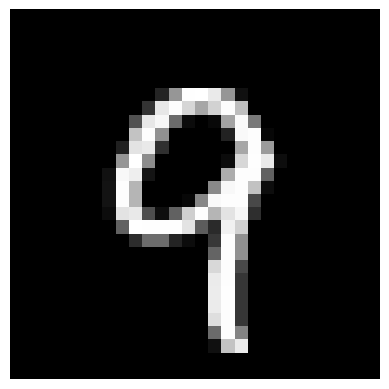

In [ ]:
# W0,W1,W2,b0,b1,b2 = ouvrir()
example()

